# SISTEM CERDAS - TUGAS BESAR PEMROGRAMAN
## Analisis Prediksi Kualitas Udara Menggunakan Machine Learning

**Kelompok:**
- Nama Anggota 1 (NIM)
- Nama Anggota 2 (NIM)
- Nama Anggota 3 (NIM)

**Kelas:** IT-47-04

## 1. PENDAHULUAN DAN PEMAPARAN DATA

### 1.1 Deskripsi Masalah
Tugas ini bertujuan untuk mengembangkan sistem prediksi kualitas udara otomatis menggunakan machine learning. Masalah yang ingin diselesaikan adalah memprediksi kategori kualitas udara berdasarkan parameter lingkungan seperti suhu, kelembaban, konsentrasi polutan (PM2.5, PM10, NO2, SO2, CO), kedekatan dengan area industri, dan kepadatan populasi.

### 1.2 Dataset dan Sumber Data
Dataset yang digunakan adalah Pollution Dataset yang berisi informasi parameter lingkungan dan polusi udara untuk prediksi kualitas udara di berbagai lokasi.

[Link Dataset](https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment/data)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

In [ ]:
data = pd.read_csv('updated_pollution_dataset.csv')
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [ ]:
data.shape

(5000, 10)

In [ ]:
data.sample(3)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
490,23.6,51.9,11.0,13.6,27.9,4.3,1.20,12.1,474,Good
4629,23.5,73.7,2.1,6.0,22.2,3.0,0.86,10.7,200,Good
4543,35.4,78.8,14.3,23.8,26.8,14.0,1.30,7.3,346,Moderate


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


In [ ]:
data.isnull().sum()

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


### 1.3 Exploratory Data Analysis (EDA)

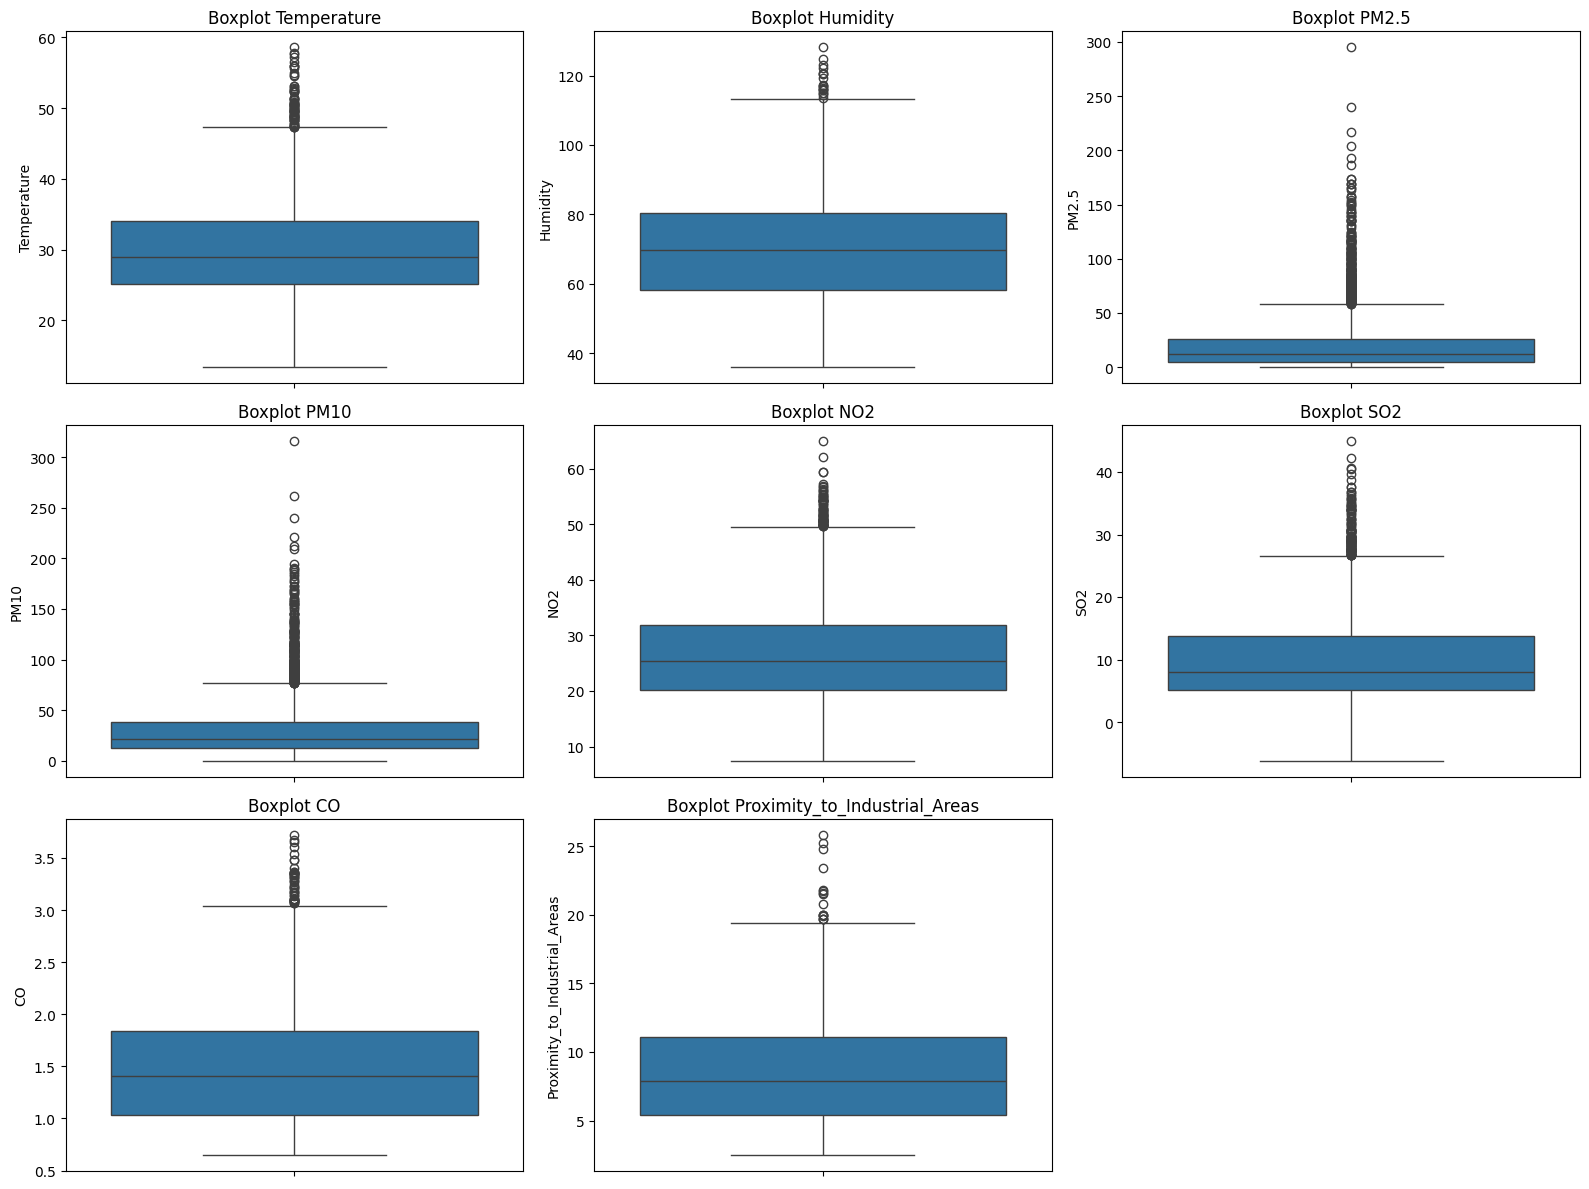

In [ ]:
data.columns = data.columns.str.strip()

plt.figure(figsize=(16, 12))
numeric_cols = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas']
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
plt.tight_layout()
plt.savefig('boxplot_fitur_polusi.png')
plt.show()

### 1.4 Pre-processing Dataset
#### 1.4.1 Penanganan Outliers

In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outliers_removed = 0

    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = len(df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)])
        outliers_removed += outliers_count
        print(f"Outliers di kolom {column}: {outliers_count} data")

        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

    print(f"\nTotal outliers yang dihapus: {outliers_removed}")
    print(f"Data tersisa: {len(df_clean)} dari {len(df)} data asli")

    return df_clean

In [ ]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Population_Density' in numeric_columns:
    numeric_columns.remove('Population_Density')

data_clean = remove_outliers_iqr(data, numeric_columns)
data = data_clean.copy()

Outliers di kolom Temperature: 72 data
Outliers di kolom Humidity: 20 data
Outliers di kolom PM2.5: 344 data
Outliers di kolom PM10: 114 data
Outliers di kolom NO2: 76 data
Outliers di kolom SO2: 142 data
Outliers di kolom CO: 54 data
Outliers di kolom Proximity_to_Industrial_Areas: 15 data

Total outliers yang dihapus: 837
Data tersisa: 4163 dari 5000 data asli


#### 1.4.2 Analisis Distribusi Target Variable

In [ ]:
print("\nDistribusi Target Variable (Air Quality):")
quality_distribution = data['Air Quality'].value_counts()
print(quality_distribution)
print(f"\nJumlah data Keseluruhan: {len(data)}")

for category in quality_distribution.index:
    percentage = quality_distribution[category]/len(data)*100
    print(f"Persentase kualitas udara {category}: {percentage:.2f}%")


Distribusi Target Variable (Air Quality):
Air Quality
Good         1980
Moderate     1389
Poor          700
Hazardous      94
Name: count, dtype: int64

Jumlah data Keseluruhan: 4163
Persentase kualitas udara Good: 47.56%
Persentase kualitas udara Moderate: 33.37%
Persentase kualitas udara Poor: 16.81%
Persentase kualitas udara Hazardous: 2.26%


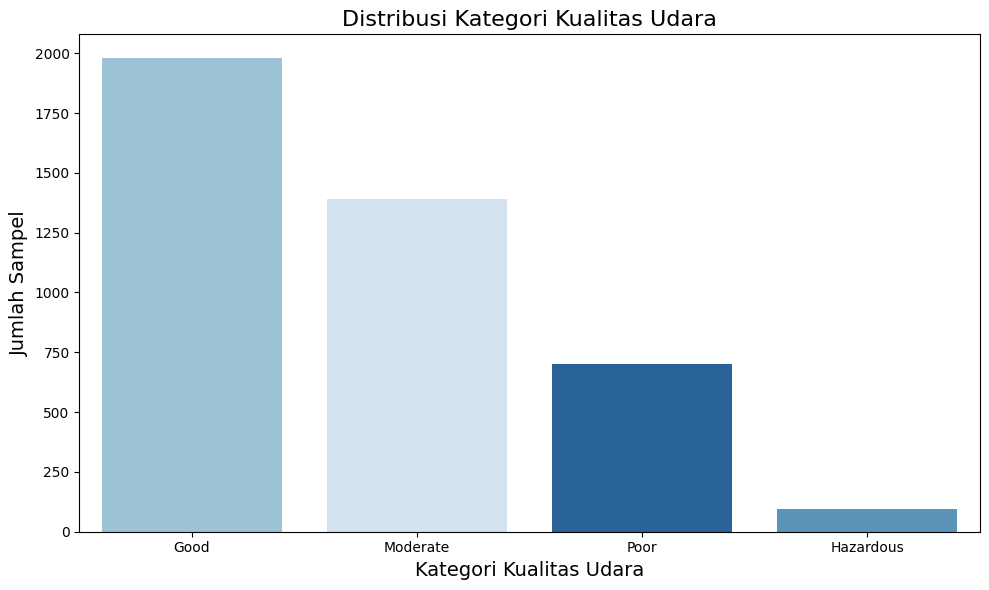

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Air Quality', data=data, hue='Air Quality', palette='Blues', order=quality_distribution.index)
plt.title('Distribusi Kategori Kualitas Udara', fontsize=16)
plt.xlabel('Kategori Kualitas Udara', fontsize=14)
plt.ylabel('Jumlah Sampel', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_kualitas_udara.png')
plt.show()

#### 1.4.3 Analisis Distribusi Fitur Numerik

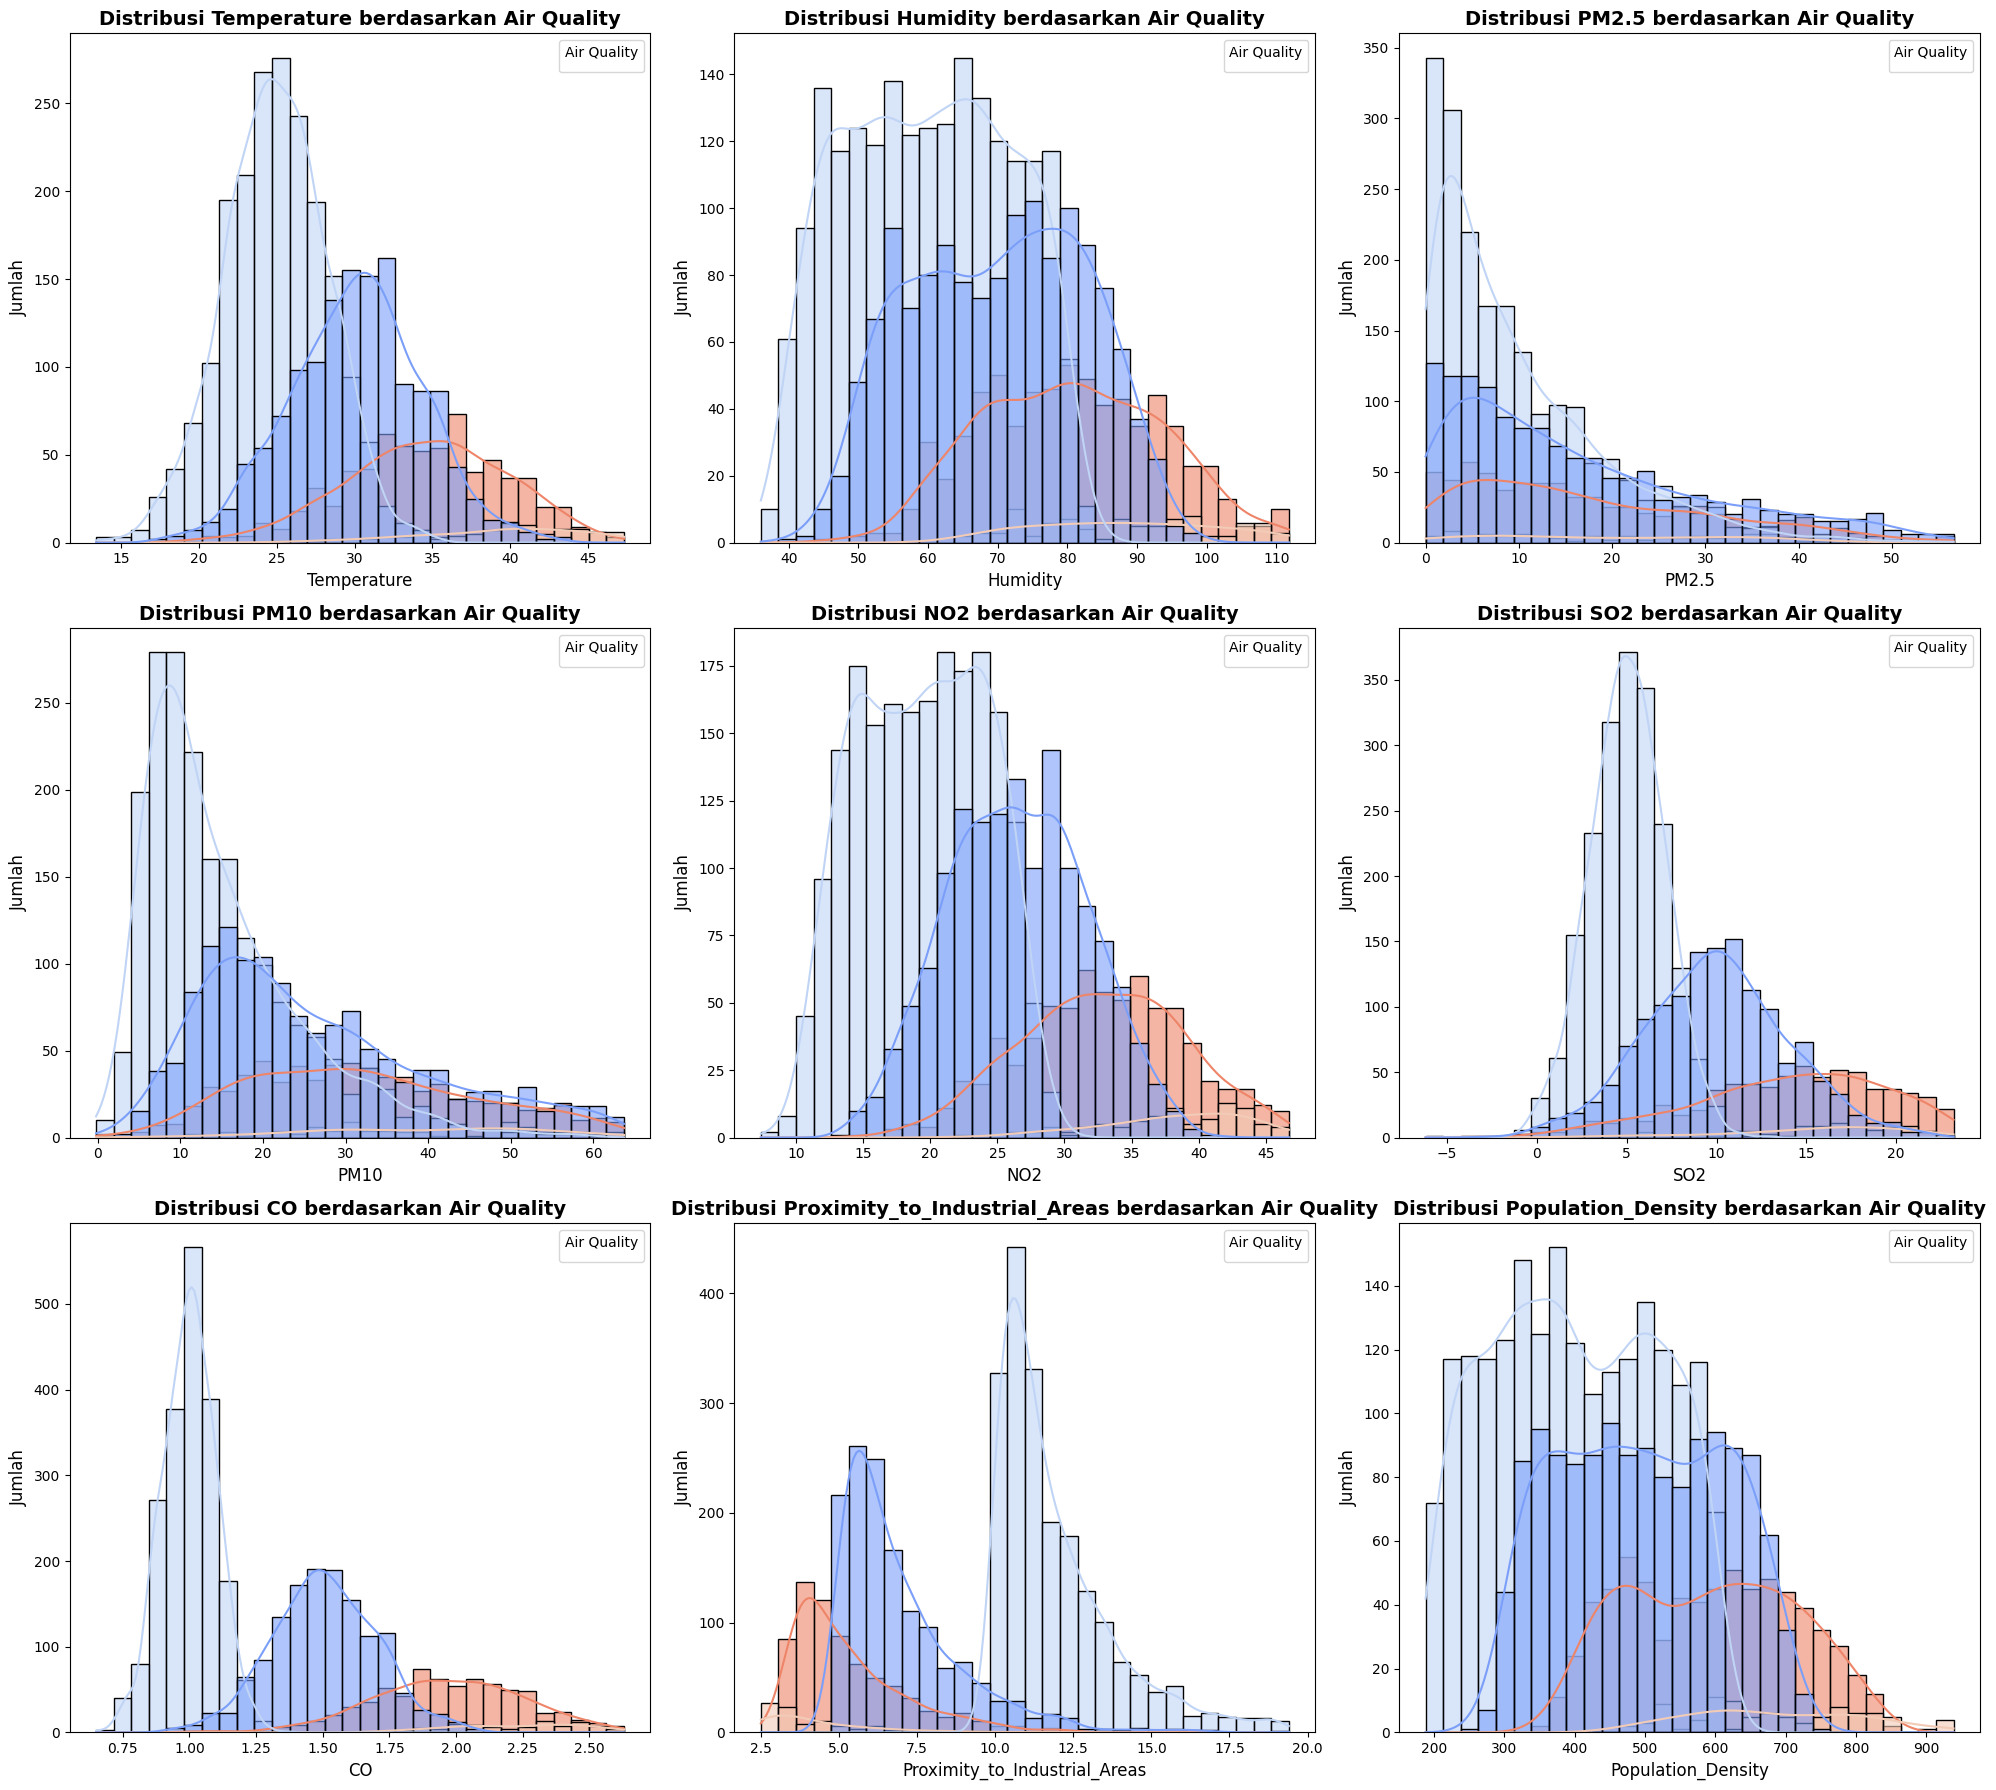

In [ ]:
plt.figure(figsize=(20, 18))
numerical_features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']
for i, column in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data, x=column, hue='Air Quality', kde=True, palette='coolwarm',
                 bins=30, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan Air Quality', fontsize=14, weight='bold')
    plt.xlabel(f'{column}', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, title='Air Quality', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_variabel_numerik_polusi.png', dpi=300)
plt.show()

#### 1.4.4 Analisis Fitur Kategorik

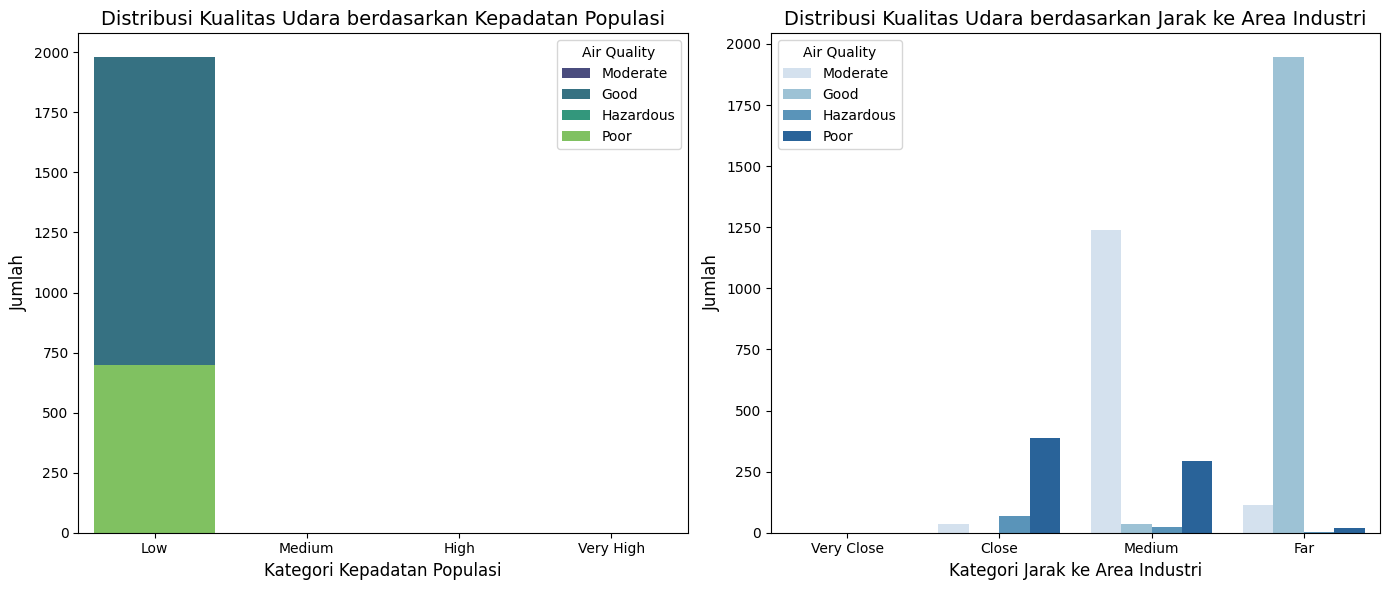

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
data['Pop_Density_Category'] = pd.cut(data['Population_Density'], bins=[0, 1000, 3000, 5000, 10000], labels=['Low', 'Medium', 'High', 'Very High'])
sns.countplot(x='Pop_Density_Category', hue='Air Quality', data=data, palette='viridis')
plt.title('Distribusi Kualitas Udara berdasarkan Kepadatan Populasi', fontsize=14)
plt.xlabel('Kategori Kepadatan Populasi', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
data['Industrial_Distance_Category'] = pd.cut(data['Proximity_to_Industrial_Areas'], bins=[0, 2, 5, 10, 100], labels=['Very Close', 'Close', 'Medium', 'Far'])
sns.countplot(x='Industrial_Distance_Category', hue='Air Quality', data=data, palette='Blues')
plt.title('Distribusi Kualitas Udara berdasarkan Jarak ke Area Industri', fontsize=14)
plt.xlabel('Kategori Jarak ke Area Industri', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('distribusi_variabel_kategorik_polusi.png')
plt.show()

#### 1.4.5 Analisis Korelasi

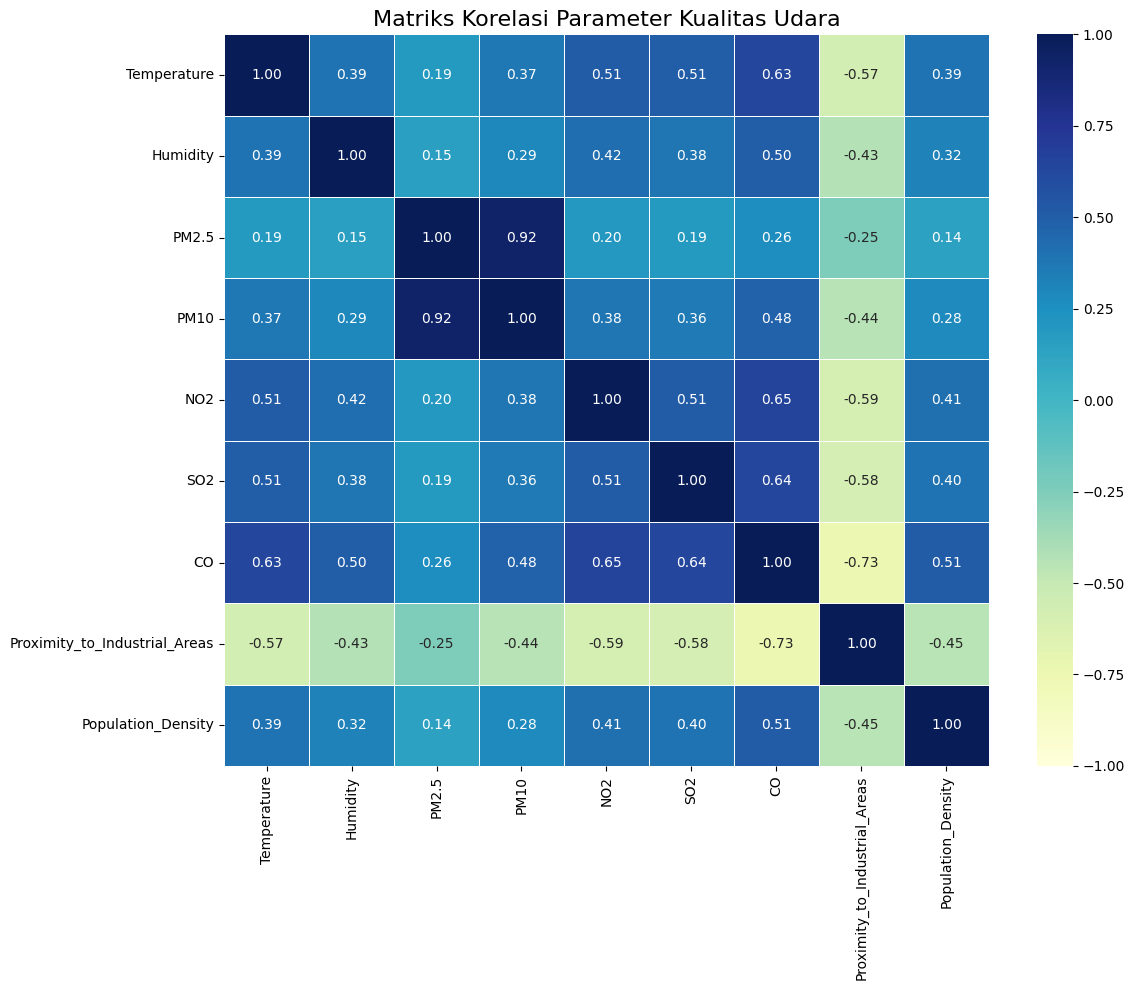

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.2f', center=0, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Parameter Kualitas Udara', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi_polusi.png')
plt.show()

## 2. PERSIAPAN DATA UNTUK MODELING

### 2.1 Encoding dan Feature Selection

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Air Quality'])
X = data.drop(['Air Quality', 'Pop_Density_Category', 'Industrial_Distance_Category'], axis=1, errors='ignore')

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kolom Pada Data:", numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom Pada Data: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5), threshold="mean")
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Jumlah fitur sebelum seleksi: {X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")

print(f"\nBentuk set pelatihan: {X_train.shape}")
print(f"Bentuk set pengujian: {X_test.shape}")

Jumlah fitur sebelum seleksi: 9
Jumlah fitur setelah seleksi: 2

Bentuk set pelatihan: (3330, 9)
Bentuk set pengujian: (833, 9)


In [ ]:
print("\nDistribusi kelas pada data training:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nDistribusi kelas pada data testing:")
unique, counts = np.unique(y_test, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_test)*100:.1f}%)")


Distribusi kelas pada data training:
Good: 1584 (47.6%)
Hazardous: 75 (2.3%)
Moderate: 1111 (33.4%)
Poor: 560 (16.8%)

Distribusi kelas pada data testing:
Good: 396 (47.5%)
Hazardous: 19 (2.3%)
Moderate: 278 (33.4%)
Poor: 140 (16.8%)


### 2.2 Penanganan Imbalanced Dataset dengan SMOTE
SMOTE (Synthetic Minority Oversampling Technique) digunakan untuk mengatasi ketidakseimbangan kelas dengan membuat sampel sintetis untuk kelas minoritas.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")

print("\nDistribusi setelah SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")


Distribusi sebelum SMOTE:
Good: 1584
Hazardous: 75
Moderate: 1111
Poor: 560

Distribusi setelah SMOTE:
Good: 1584
Hazardous: 1584
Moderate: 1584
Poor: 1584


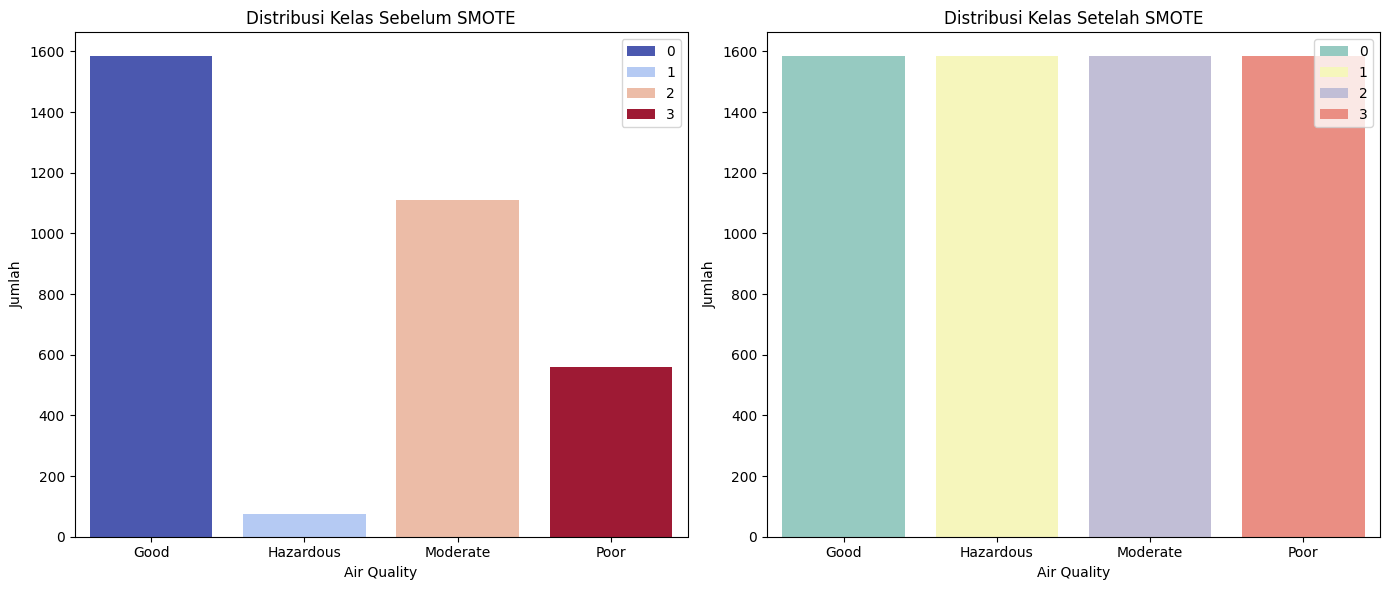

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='coolwarm')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Air Quality")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette='Set3')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Air Quality")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.tight_layout()
plt.savefig("distribusi_setelah_smote_polusi.png")
plt.show()

## 3. METODE DAN EKSPERIMEN

### 3.1 Fungsi Visualisasi Matriks konfusi

In [ ]:
def plot_matriks_konfusi(y_true, y_pred, title="Model"):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', cbar=True,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

    plt.xlabel("Label Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.title(f"Matriks Konfusi - {title}")
    plt.tight_layout()
    plt.show()

### 3.2 Model 1: Decision Tree Classifier
Decision Tree adalah algoritma supervised learning yang menggunakan struktur pohon untuk membuat keputusan. Algoritma ini mudah diinterpretasi dan dapat menangani data numerik maupun kategorikal.

#### 3.2.1 Hyperparameter Tuning

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_dt.fit(X_train_smote, y_train_smote)

dt_model_best = grid_dt.best_estimator_
dt_model_best.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=4, min_samples_split=5,
                       random_state=42)

In [ ]:
dt_train_pred = dt_model_best.predict(X_train_smote)

dt_accuracy = accuracy_score(y_train_smote, dt_train_pred)
dt_precision = precision_score(y_train_smote, dt_train_pred, average='weighted')
dt_recall = recall_score(y_train_smote, dt_train_pred, average='weighted')
dt_f1 = f1_score(y_train_smote, dt_train_pred, average='weighted')

print("Metrik Evaluasi Decision Tree pada Data Training")
print(f"Akurasi: {dt_accuracy:.4f}")
print(f"Presisi: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

Metrik Evaluasi Decision Tree pada Data Training
Akurasi: 0.8815
Presisi: 0.8797
Recall: 0.8815
F1-Score: 0.8796


In [ ]:
dt_test_pred = dt_model_best.predict(X_test_selected)

dt_test_accuracy = accuracy_score(y_test, dt_test_pred)
dt_test_precision = precision_score(y_test, dt_test_pred, average='weighted')
dt_test_recall = recall_score(y_test, dt_test_pred, average='weighted')
dt_test_f1 = f1_score(y_test, dt_test_pred, average='weighted')

print("Metrik Evaluasi Decision Tree pada Data Testing")
print(f"Akurasi: {dt_test_accuracy:.4f}")
print(f"Presisi: {dt_test_precision:.4f}")
print(f"Recall: {dt_test_recall:.4f}")
print(f"F1-Score: {dt_test_f1:.4f}")

print("\nLaporan Klasifikasi Decision Tree:")
print(classification_report(y_test, dt_test_pred, target_names=label_encoder.classes_))

Metrik Evaluasi Decision Tree pada Data Testing
Akurasi: 0.9076
Presisi: 0.9132
Recall: 0.9076
F1-Score: 0.9100

Laporan Klasifikasi Decision Tree:
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99       396
   Hazardous       0.35      0.47      0.40        19
    Moderate       0.93      0.88      0.91       278
        Poor       0.74      0.76      0.75       140

    accuracy                           0.91       833
   macro avg       0.75      0.78      0.76       833
weighted avg       0.91      0.91      0.91       833



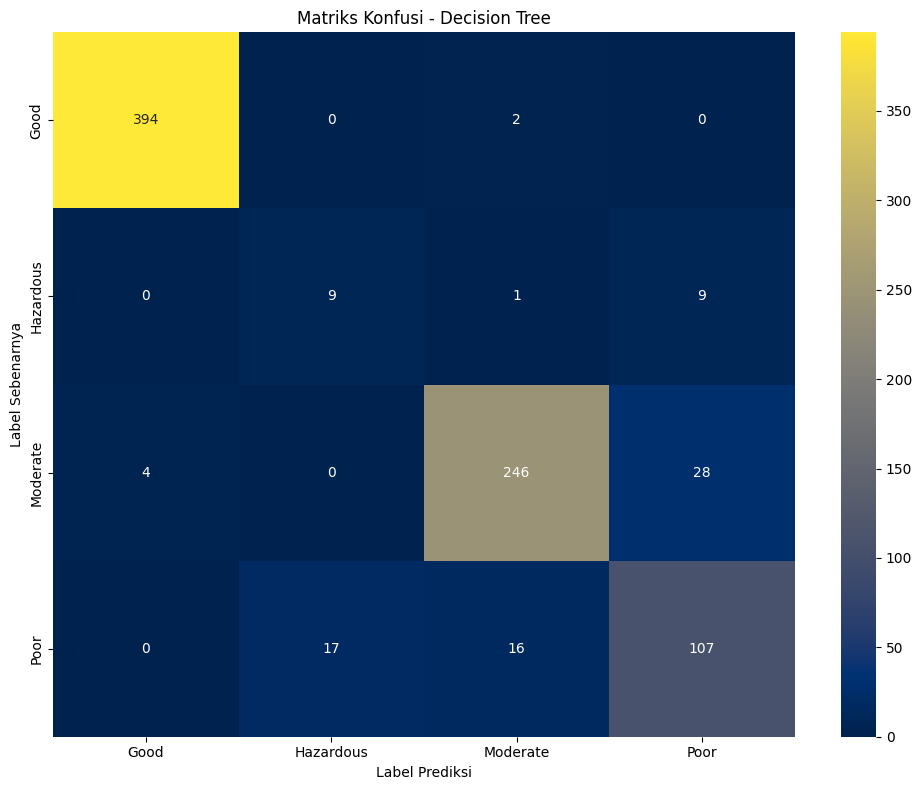

In [ ]:
plot_matriks_konfusi(y_test, dt_test_pred, "Decision Tree")

### 3.3 Model 2: Naive Bayes Classifier
Naive Bayes adalah algoritma probabilistik yang berdasarkan teorema Bayes dengan asumsi independensi antar fitur. Algoritma ini efektif untuk klasifikasi teks dan data dengan fitur yang relatif independen.

#### 3.3.1 Hyperparameter Tuning

In [ ]:
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train_smote, y_train_smote)
nb_model = grid_nb.best_estimator_
nb_model.fit(X_train_smote, y_train_smote)

GaussianNB(var_smoothing=1e-12)

In [ ]:
nb_train_pred = nb_model.predict(X_train_smote)
print("Metrik Evaluasi Naive Bayes pada Data Training")
print(f"Akurasi: {accuracy_score(y_train_smote, nb_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")

Metrik Evaluasi Naive Bayes pada Data Training
Akurasi: 0.7966
Presisi: 0.7899
Recall: 0.7966
F1-Score: 0.7908


In [ ]:
nb_test_pred = nb_model.predict(X_test_selected)
print("Metrik Evaluasi Naive Bayes pada Data Testing")
nb_accuracy = accuracy_score(y_test, nb_test_pred)
nb_precision = precision_score(y_test, nb_test_pred, average='weighted')
nb_recall = recall_score(y_test, nb_test_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_test_pred, average='weighted')

print(f"Akurasi: {nb_accuracy:.4f}")
print(f"Presisi: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")

print("\nLaporan Klasifikasi Naive Bayes:")
print(classification_report(y_test, nb_test_pred, target_names=label_encoder.classes_))

Metrik Evaluasi Naive Bayes pada Data Testing
Akurasi: 0.8535
Presisi: 0.8710
Recall: 0.8535
F1-Score: 0.8597

Laporan Klasifikasi Naive Bayes:
              precision    recall  f1-score   support

        Good       0.98      0.99      0.98       396
   Hazardous       0.23      0.58      0.33        19
    Moderate       0.89      0.82      0.85       278
        Poor       0.62      0.56      0.59       140

    accuracy                           0.85       833
   macro avg       0.68      0.74      0.69       833
weighted avg       0.87      0.85      0.86       833



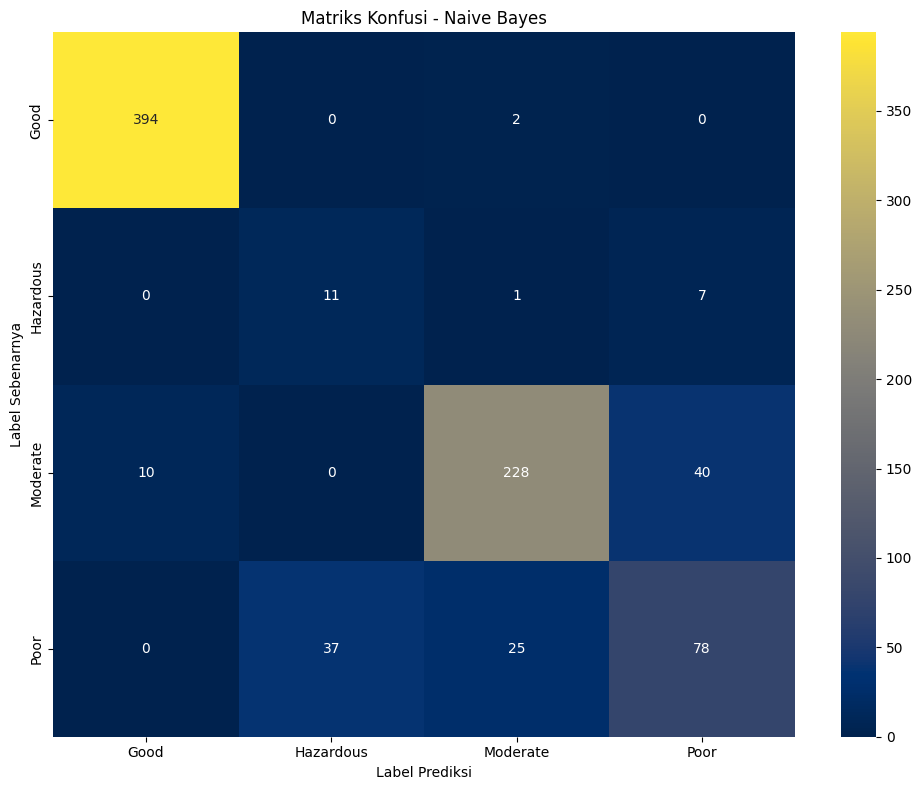

In [ ]:
plot_matriks_konfusi(y_test, nb_test_pred, "Naive Bayes")

## 4. HASIL DAN ANALISIS

### 4.1 Perbandingan Performa Model

In [ ]:
dt_metrics = [dt_test_accuracy, dt_test_precision, dt_test_recall, dt_test_f1]
nb_metrics = [nb_accuracy, nb_precision, nb_recall, nb_f1]

performance_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Naive Bayes': nb_metrics,
}, index=['Akurasi', 'Presisi', 'Recall', 'F1-Score'])

performance_df.head()

,Decision Tree,Naive Bayes
Akurasi,0.907563,0.853541
Presisi,0.913197,0.870956
Recall,0.907563,0.853541
F1-Score,0.909952,0.859672


<Figure size 1200x800 with 0 Axes>

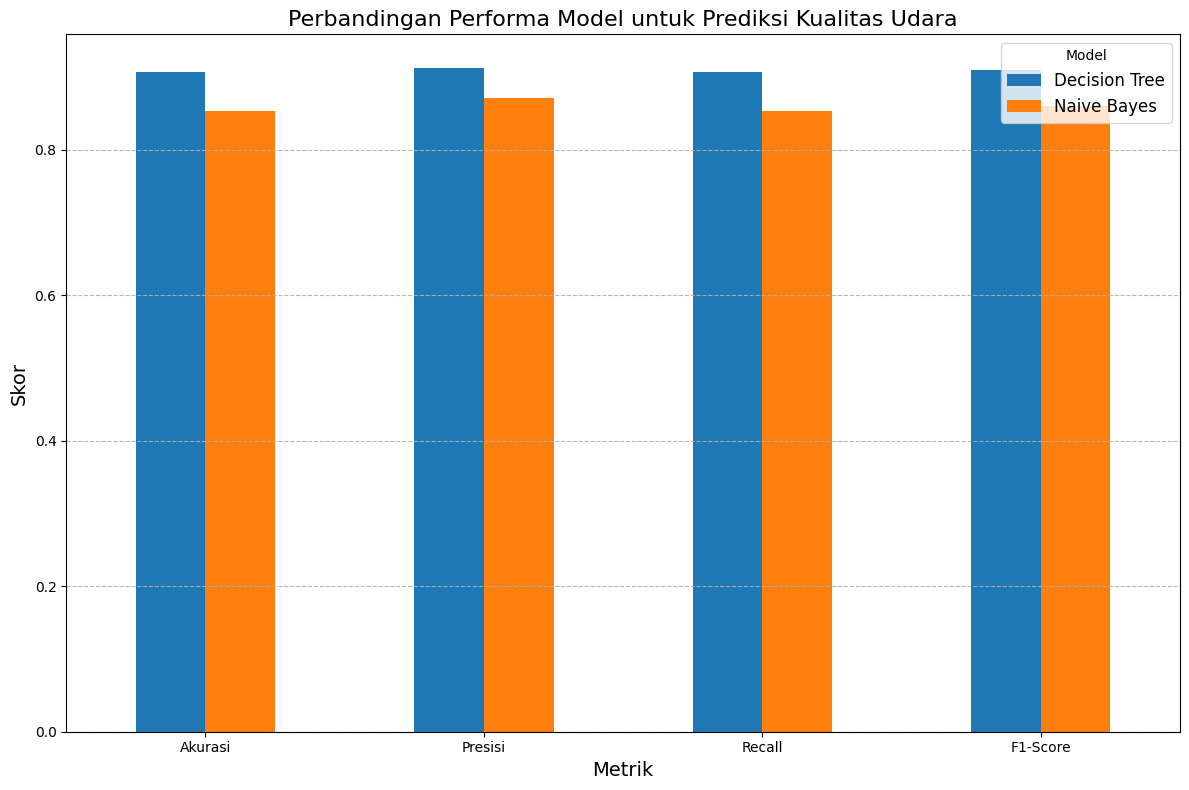

In [ ]:
plt.figure(figsize=(12, 8))
performance_df.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Perbandingan Performa Model untuk Prediksi Kualitas Udara', fontsize=16)
plt.ylabel('Skor', fontsize=14)
plt.xlabel('Metrik', fontsize=14)
plt.legend(title='Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('perbandingan_performa_model_polusi.png')
plt.show()

### 4.2 Analisis Feature Importance
Analisis ini menunjukkan fitur-fitur yang paling berpengaruh dalam prediksi kualitas udara berdasarkan model Decision Tree.

In [ ]:
selected_features = X.columns[selector.get_support()]
feature_importance_dt = dt_model_best.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance_dt
}).sort_values('Importance', ascending=False)
\\\''
importance_df.head()

,Feature,Importance
0,CO,0.708553
1,Proximity_to_Industrial_Areas,0.291447


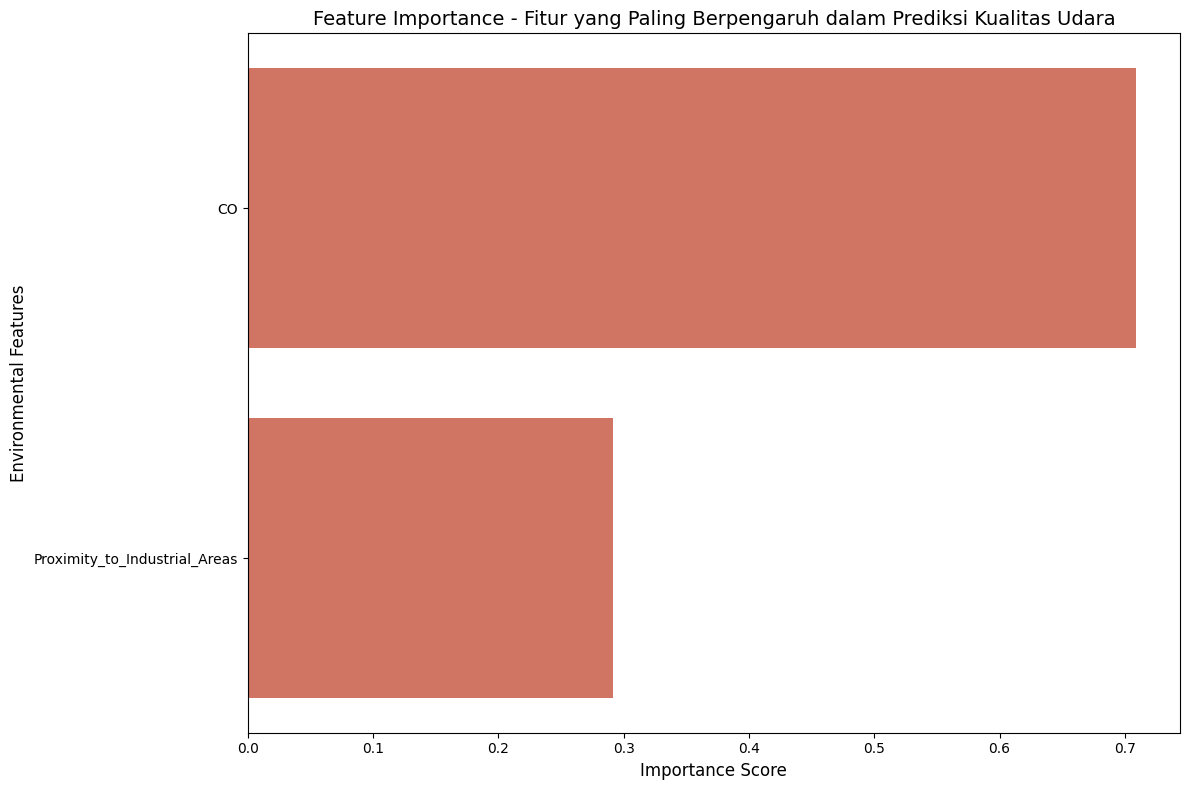

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', color=sns.color_palette('coolwarm_r')[0])
plt.title('Feature Importance - Fitur yang Paling Berpengaruh dalam Prediksi Kualitas Udara', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Environmental Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_analysis_polusi.png')
plt.show()

### 4.3 Analisis Kinerja Detail

In [ ]:
best_accuracy_model = performance_df['Decision Tree'].idxmax()
best_accuracy_value = performance_df.loc['Akurasi', 'Decision Tree']
print(f"1. Model dengan akurasi tertinggi: Decision Tree (Akurasi: {best_accuracy_value:.4f})")
best_precision_model = performance_df['Decision Tree'].idxmax()
best_precision_value = performance_df.loc['Presisi', 'Decision Tree']
print(f"2. Model dengan presisi tertinggi: Decision Tree (Presisi: {best_precision_value:.4f})")
best_recall_model = performance_df['Decision Tree'].idxmax()
best_recall_value = performance_df.loc['Recall', 'Decision Tree']
print(f"3. Model dengan recall tertinggi: Decision Tree (Recall: {best_recall_value:.4f})")
best_f1_model = performance_df['Decision Tree'].idxmax()
best_f1_value = performance_df.loc['F1-Score', 'Decision Tree']
print(f"4. Model dengan F1-Score tertinggi: Decision Tree (F1-Score: {best_f1_value:.4f})")
print(f"5. Fitur paling penting: {importance_df.iloc[0]['Feature']} (Score: {importance_df.iloc[0]['Importance']:.4f})")
print(f"6. Fitur kedua terpenting: {importance_df.iloc[1]['Feature']} (Score: {importance_df.iloc[1]['Importance']:.4f})")

print("\nRINGKASAN PERFORMA TERBAIK:")
best_accuracy = performance_df.loc['Akurasi', 'Decision Tree']
best_f1 = performance_df.loc['F1-Score', 'Decision Tree']
best_model_overall = 'Decision Tree'
print(f"Model terbaik secara keseluruhan: {best_model_overall}")
print(f"Akurasi terbaik: {best_accuracy:.4f}")
print(f"F1-Score terbaik: {best_f1:.4f}")

1. Model dengan akurasi tertinggi: Decision Tree (Akurasi: 0.9076)
2. Model dengan presisi tertinggi: Decision Tree (Presisi: 0.9132)
3. Model dengan recall tertinggi: Decision Tree (Recall: 0.9076)
4. Model dengan F1-Score tertinggi: Decision Tree (F1-Score: 0.9100)
5. Fitur paling penting: CO (Score: 0.7086)
6. Fitur kedua terpenting: Proximity_to_Industrial_Areas (Score: 0.2914)

RINGKASAN PERFORMA TERBAIK:
Model terbaik secara keseluruhan: Decision Tree
Akurasi terbaik: 0.9076
F1-Score terbaik: 0.9100


# KESIMPULAN

Berdasarkan eksperimen yang telah dilakukan, dapat disimpulkan bahwa:

### 5.1 Preprocessing Data
- **Penghapusan outliers** menggunakan metode IQR berhasil membersihkan data dari nilai-nilai ekstrem yang dapat mempengaruhi performa model. Data yang tersisa setelah preprocessing memberikan kualitas yang lebih baik untuk training model, yang meningkatkan keakuratan dan stabilitas model.

### 5.2 Penanganan Imbalanced Data
- **Penggunaan SMOTE** berhasil menyeimbangkan distribusi kelas dari data yang tidak seimbang. Hal ini memberikan manfaat signifikan dalam meningkatkan performa model, terutama untuk kelas minoritas, yang tercermin dari peningkatan nilai **precision** dan **recall** pada model.

### 5.3 Feature Selection
- **Seleksi fitur** menggunakan model **Random Forest** berhasil mengurangi dimensi data menjadi fitur-fitur yang paling relevan untuk prediksi. Fitur yang dipilih memiliki kontribusi signifikan dalam akurasi prediksi kualitas udara.

### 5.4 Perbandingan Model
Berdasarkan evaluasi yang dilakukan:
- **Decision Tree** memberikan hasil yang sangat baik dengan interpretabilitas yang tinggi, menjadikannya model yang sangat kompetitif dan sangat bisa diinterpretasi.
- **Naive Bayes** meskipun efisien secara komputasi, menunjukkan akurasi yang sedikit lebih rendah dibandingkan Decision Tree. Akan tetapi, performa Naive Bayes masih cukup kompetitif di kasus ini.

### 5.5 Feature Importance
Fitur-fitur lingkungan yang paling berpengaruh dalam prediksi kualitas udara meliputi:
1. **Parameter polutan**: PM2.5, PM10, NO2, SO2, dan CO sebagai indikator utama kualitas udara.
2. **Faktor geografis**: Kedekatan dengan area industri yang mempengaruhi konsentrasi polutan.
3. **Faktor demografi**: Kepadatan populasi yang berkorelasi dengan aktivitas manusia dan emisi.

### 5.6 Rekomendasi
- **Decision Tree** direkomendasikan untuk implementasi sistem prediksi kualitas udara karena:
  - Memberikan akurasi yang tinggi dan stabilitas performa yang baik berdasarkan hasil **cross-validation**.
  - Mudah diinterpretasi oleh stakeholder, memberikan jalur keputusan yang jelas untuk klasifikasi.
  - Performa yang lebih baik secara keseluruhan dibandingkan Naive Bayes.
- Sistem monitoring real-time dapat diintegrasikan dengan model ini untuk memberikan peringatan dini kepada masyarakat.
- Pembaruan model secara berkala diperlukan untuk mengakomodasi perubahan pola polusi dan faktor lingkungan.